# BIOSNAP Model Comparison Visualization

This notebook compares the performance of four models trained on the BIOSNAP dataset for 15 epochs:
1. **Baseline (SimpleCoembedding)**
2. **ResidualCoembedding**
3. **DeepCoembedding**
4. **CrossAttentionCoembedding**

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [ ]:
# Define paths to history files
base_path = "best_models"
model_paths = {
    "Baseline": os.path.join(base_path, "biosnap_baseline_contrastive", "history.json"),
    "Residual": os.path.join(base_path, "biosnap_residual_improved", "history.json"),
    "Deep MLP": os.path.join(base_path, "biosnap_deep_contrastive", "history.json"),
    "Cross Attention": os.path.join(base_path, "biosnap_crossattn_contrastive_fixed", "history.json")
}

# Load data
data = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        with open(path, 'r') as f:
            data[name] = json.load(f)
    else:
        print(f"Warning: File not found for {name} at {path}")

In [3]:
# Helper function to extract metrics
def extract_metrics(data_dict, metric_name):
    df_list = []
    for model_name, history in data_dict.items():
        if metric_name in history:
            values = history[metric_name]
            epochs = range(1, len(values) + 1)
            df_list.append(pd.DataFrame({
                "Epoch": epochs,
                "Model": model_name,
                metric_name: values
            }))
    return pd.concat(df_list) if df_list else pd.DataFrame()

## Training Loss Comparison

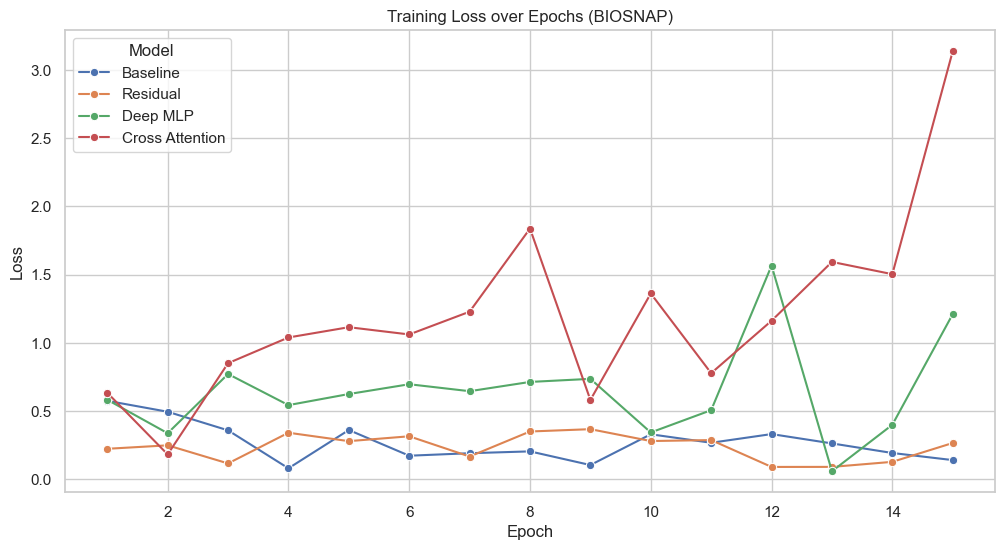

In [4]:
df_loss = extract_metrics(data, "train_loss")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_loss, x="Epoch", y="train_loss", hue="Model", marker="o")
plt.title("Training Loss over Epochs (BIOSNAP)")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(title="Model")
plt.show()

## Validation AUPR Comparison

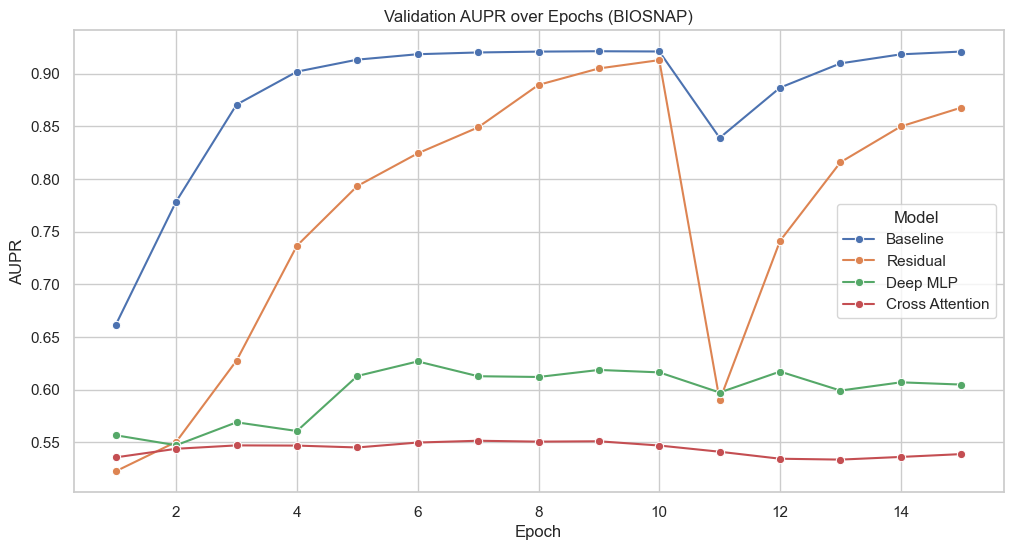

In [5]:
df_aupr = extract_metrics(data, "val_aupr")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_aupr, x="Epoch", y="val_aupr", hue="Model", marker="o")
plt.title("Validation AUPR over Epochs (BIOSNAP)")
plt.ylabel("AUPR")
plt.xlabel("Epoch")
plt.legend(title="Model")
plt.show()

## Validation AUROC Comparison

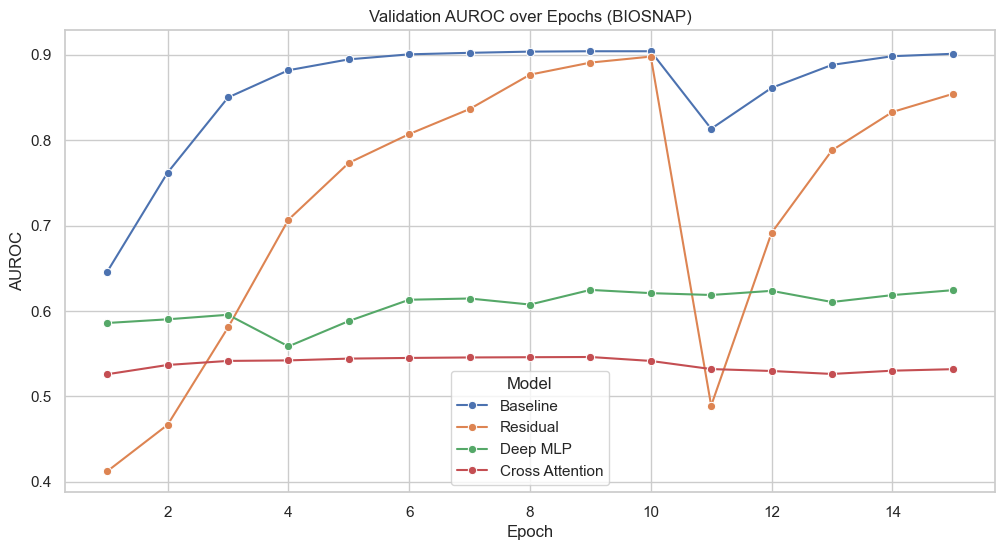

In [6]:
df_auroc = extract_metrics(data, "val_auroc")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_auroc, x="Epoch", y="val_auroc", hue="Model", marker="o")
plt.title("Validation AUROC over Epochs (BIOSNAP)")
plt.ylabel("AUROC")
plt.xlabel("Epoch")
plt.legend(title="Model")
plt.show()

## Final Test Results Comparison

             Model  Test AUPR  Test AUROC  Epochs Trained
0         Baseline   0.922245    0.906137            15.0
1         Residual   0.917583    0.906018            15.0
2         Deep MLP   0.606902    0.595873            15.0
3  Cross Attention   0.530743    0.529053            15.0


/var/folders/yh/wdfg42fn3q14n27yd20290nh0000gn/T/ipykernel_35653/127741872.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_test, x="Model", y="Test AUPR", palette="viridis")


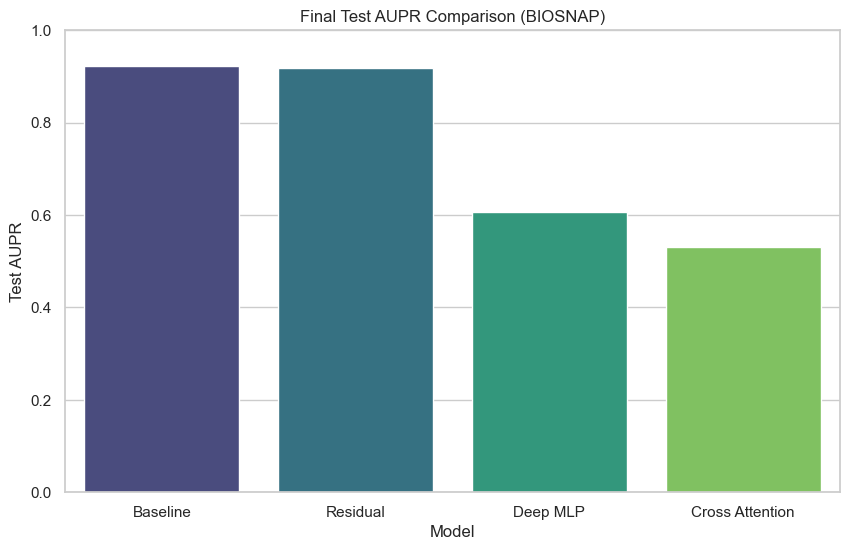

In [7]:
test_results = []
for name, history in data.items():
    if "test_results" in history:
        res = history["test_results"]
        test_results.append({
            "Model": name,
            "Test AUPR": res.get("test/aupr", 0),
            "Test AUROC": res.get("test/auroc", 0),
            "Epochs Trained": res.get("epoch", 0)
        })

df_test = pd.DataFrame(test_results)
print(df_test)

# Bar plot for Test AUPR
plt.figure(figsize=(10, 6))
sns.barplot(data=df_test, x="Model", y="Test AUPR", palette="viridis")
plt.title("Final Test AUPR Comparison (BIOSNAP)")
plt.ylim(0, 1.0)
plt.show()